In [ ]:
!pip install kaggle

In [ ]:
import kagglehub
import shutil
import os

path = kagglehub.dataset_download("abdurraziq01/cloud-computing-performance-metrics")

dataset_version_path = os.path.join(path)

target_directory = '/content/'

os.makedirs(target_directory, exist_ok=True)

for filename in os.listdir(dataset_version_path):
    file_path = os.path.join(dataset_version_path, filename)
    if os.path.isfile(file_path):
        shutil.move(file_path, os.path.join(target_directory, filename))

print(f"Dataset has been moved to {target_directory}")


Dataset has been moved to /content/


In [ ]:
from pyspark.sql import SparkSession

In [ ]:
from pyspark.sql import functions as F

In [ ]:
spark = SparkSession.builder.appName("Cloud_Resource_Optimization").getOrCreate()

In [ ]:
df = spark.read.csv("/content/vmCloud_data.csv", header=True, inferSchema=True)

In [ ]:
df.show(5)

+--------------------+-------------------+-----------------+------------------+------------------+------------------+-------------------------+------------------+-------------------+---------+-------------+-----------+
|               vm_id|          timestamp|        cpu_usage|      memory_usage|   network_traffic| power_consumption|num_executed_instructions|    execution_time|  energy_efficiency|task_type|task_priority|task_status|
+--------------------+-------------------+-----------------+------------------+------------------+------------------+-------------------------+------------------+-------------------+---------+-------------+-----------+
|c5215826-6237-4a3...|2023-01-25 09:10:54|54.88135039273247| 78.95086101800565|164.77597272736512| 287.8089860943348|                   7527.0| 69.34557502116084| 0.5535890138304125|  network|       medium|    waiting|
|29690bc6-1f34-403...|2023-01-26 04:46:34|71.51893663724195|29.901882588683115|              NULL|362.27356881966176|       

In [ ]:
df.printSchema()

root
 |-- vm_id: string (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- cpu_usage: double (nullable = true)
 |-- memory_usage: double (nullable = true)
 |-- network_traffic: double (nullable = true)
 |-- power_consumption: double (nullable = true)
 |-- num_executed_instructions: double (nullable = true)
 |-- execution_time: double (nullable = true)
 |-- energy_efficiency: double (nullable = true)
 |-- task_type: string (nullable = true)
 |-- task_priority: string (nullable = true)
 |-- task_status: string (nullable = true)



In [ ]:
df.columns

['vm_id',
 'timestamp',
 'cpu_usage',
 'memory_usage',
 'network_traffic',
 'power_consumption',
 'num_executed_instructions',
 'execution_time',
 'energy_efficiency',
 'task_type',
 'task_priority',
 'task_status']

In [ ]:
df.describe().toPandas().T

,0,1,2,3,4
summary,count,mean,stddev,min,max
vm_id,1799362,None,None,00001960-0da3-405c-a42a-67e6b4fa05e3,ffffff67-0737-476f-84b8-6b2541312f79
cpu_usage,1800962,50.01223220607391,28.87661216540479,7.071203171893359E-5,99.99997207656334
memory_usage,1799490,49.981898312088035,28.853261534613537,2.516783892403396E-6,99.99992772471815
network_traffic,1800519,500.007571992804,288.57934446215,1.890489775835391E-4,999.9998368051234
power_consumption,1799729,250.0583696943315,144.36342591677655,1.923801838943362E-4,499.99932548738457
num_executed_instructions,1800314,5001.897145720135,2885.2469272098933,0.0,9999.0
execution_time,1800173,49.9713270753649,28.861295423443973,1.0361921209955938E-6,99.9999919162426
energy_efficiency,1799958,0.50025235853185,0.2886668526398621,1.258445422314125E-7,0.9999999550041653
task_type,1800038,None,None,compute,network


In [ ]:
df.count()

2000000

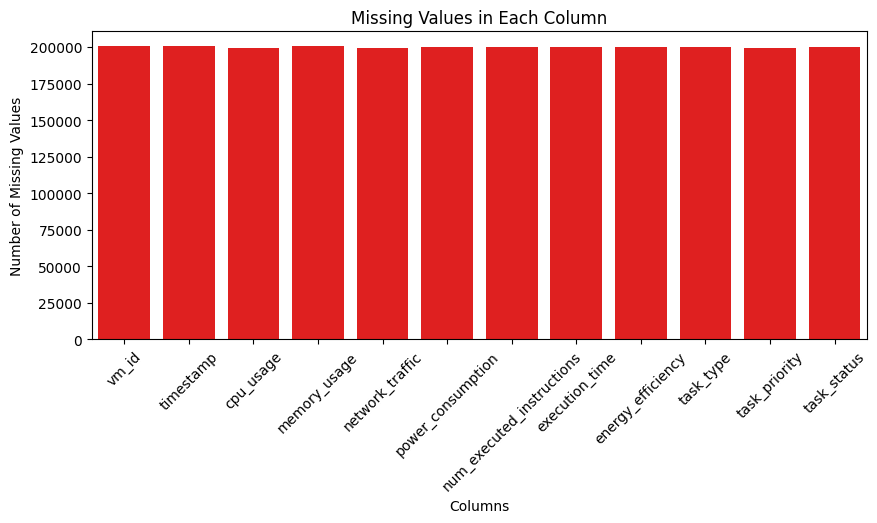

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.functions import col, sum

missing_counts = df.select([sum(col(c).isNull().cast("int")).alias(c) for c in df.columns]).toPandas()

missing_counts = missing_counts.T
missing_counts.columns = ["Missing Values"]

plt.figure(figsize=(10, 4))
sns.barplot(x=missing_counts.index, y=missing_counts["Missing Values"], color="red")
plt.xticks(rotation=45)
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.title("Missing Values in Each Column")
plt.show()

In [ ]:
from pyspark.sql.functions import mean, col, when

numeric_cols = ["cpu_usage", "memory_usage", "network_traffic", "power_consumption",
                "num_executed_instructions", "execution_time", "energy_efficiency"]

for col_name in numeric_cols:
    mean_value = df.select(mean(col(col_name))).collect()[0][0]  # Compute mean
    df = df.withColumn(col_name, when(col(col_name).isNull(), mean_value).otherwise(col(col_name)))

categorical_cols = ["task_type", "task_priority", "task_status"]

for col_name in categorical_cols:
    mode_value = df.groupBy(col_name).count().orderBy(col("count").desc()).select(col_name).first()
    if mode_value:
        mode_value = mode_value[0]
        df = df.withColumn(col_name, when(col(col_name).isNull(), mode_value).otherwise(col(col_name)))

df.show()

+--------------------+-------------------+-----------------+------------------+------------------+------------------+-------------------------+------------------+-------------------+---------+-------------+-----------+
|               vm_id|          timestamp|        cpu_usage|      memory_usage|   network_traffic| power_consumption|num_executed_instructions|    execution_time|  energy_efficiency|task_type|task_priority|task_status|
+--------------------+-------------------+-----------------+------------------+------------------+------------------+-------------------------+------------------+-------------------+---------+-------------+-----------+
|c5215826-6237-4a3...|2023-01-25 09:10:54|54.88135039273247| 78.95086101800565|164.77597272736512| 287.8089860943348|                   7527.0| 69.34557502116084| 0.5535890138304125|  network|       medium|    waiting|
|29690bc6-1f34-403...|2023-01-26 04:46:34|71.51893663724195|29.901882588683115|  500.007571992804|362.27356881966176|       

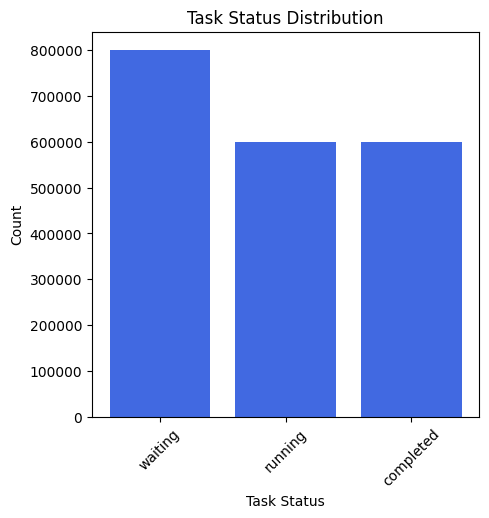

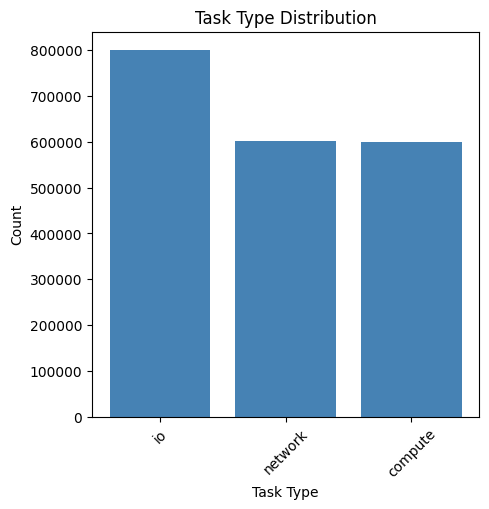

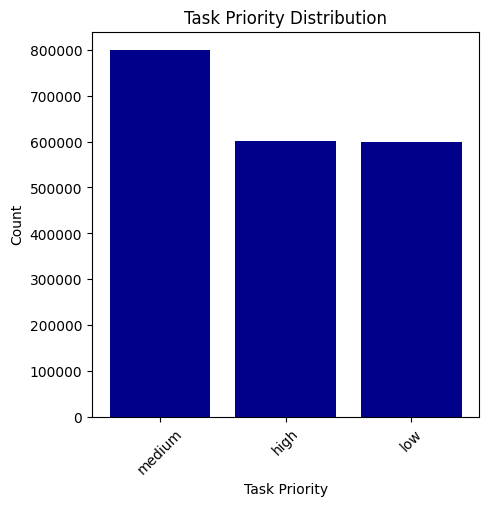

In [ ]:
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

def plot_pyspark_bar(df, column_name, title, color):
    grouped_df = df.groupBy(column_name).count().orderBy(F.desc("count"))
    data = grouped_df.collect()

    labels = [row[column_name] for row in data]
    values = [row["count"] for row in data]

    plt.figure(figsize=(5, 5))
    plt.bar(labels, values, color=color)
    plt.xlabel(column_name.replace("_", " ").title())
    plt.ylabel("Count")
    plt.title(title)
    plt.xticks(rotation=45)
    plt.show()

# Generate bar plots using PySpark DataFrames
plot_pyspark_bar(df, "task_status", "Task Status Distribution", "royalblue")
plot_pyspark_bar(df, "task_type", "Task Type Distribution", "steelblue")
plot_pyspark_bar(df, "task_priority", "Task Priority Distribution", "darkblue")

In [ ]:
from pyspark.sql.functions import skewness

skewness_values = df.select([skewness(col(c)).alias(c) for c in numeric_cols])
skewness_values.show()


+--------------------+--------------------+--------------------+--------------------+-------------------------+--------------------+--------------------+
|           cpu_usage|        memory_usage|     network_traffic|   power_consumption|num_executed_instructions|      execution_time|   energy_efficiency|
+--------------------+--------------------+--------------------+--------------------+-------------------------+--------------------+--------------------+
|-9.49383697363206...|7.141508046798409E-4|-5.55602073199567...|-0.00146372886594...|     -0.00122547835723...|0.001142003685021...|-0.00120944769303...|
+--------------------+--------------------+--------------------+--------------------+-------------------------+--------------------+--------------------+



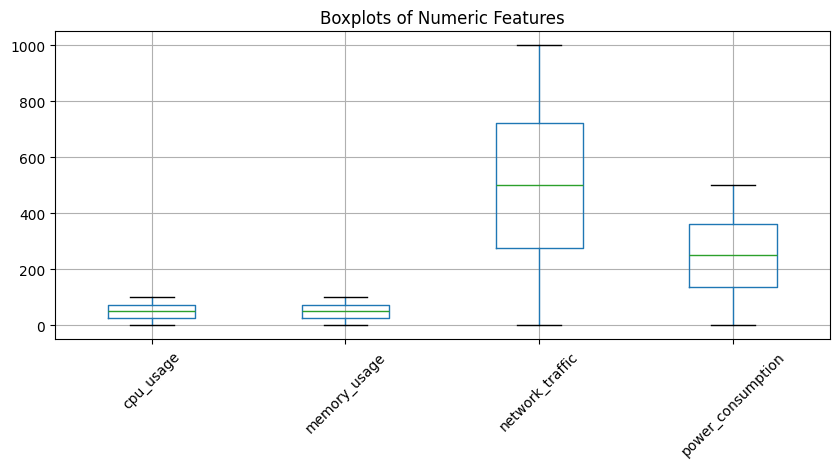

In [ ]:
from pyspark.sql.functions import percentile_approx
import matplotlib.pyplot as plt

# Define numeric features
numeric_features = ["cpu_usage", "memory_usage", "network_traffic", "power_consumption"]

# Compute quartiles (Q1, Q3) and IQR in PySpark
summary_stats = df.select(
    *[percentile_approx(col, [0.25, 0.75]).alias(col) for col in numeric_features]
).collect()[0]

# Extract Q1 and Q3 values
Q1 = {col: summary_stats[col][0] for col in numeric_features}
Q3 = {col: summary_stats[col][1] for col in numeric_features}
IQR = {col: Q3[col] - Q1[col] for col in numeric_features}

# Convert to Pandas for visualization
df_pandas = df.select(numeric_features).toPandas()

# Plot boxplots
plt.figure(figsize=(10, 4))
df_pandas.boxplot(column=numeric_features)
plt.xticks(rotation=45)
plt.title("Boxplots of Numeric Features")
plt.show()


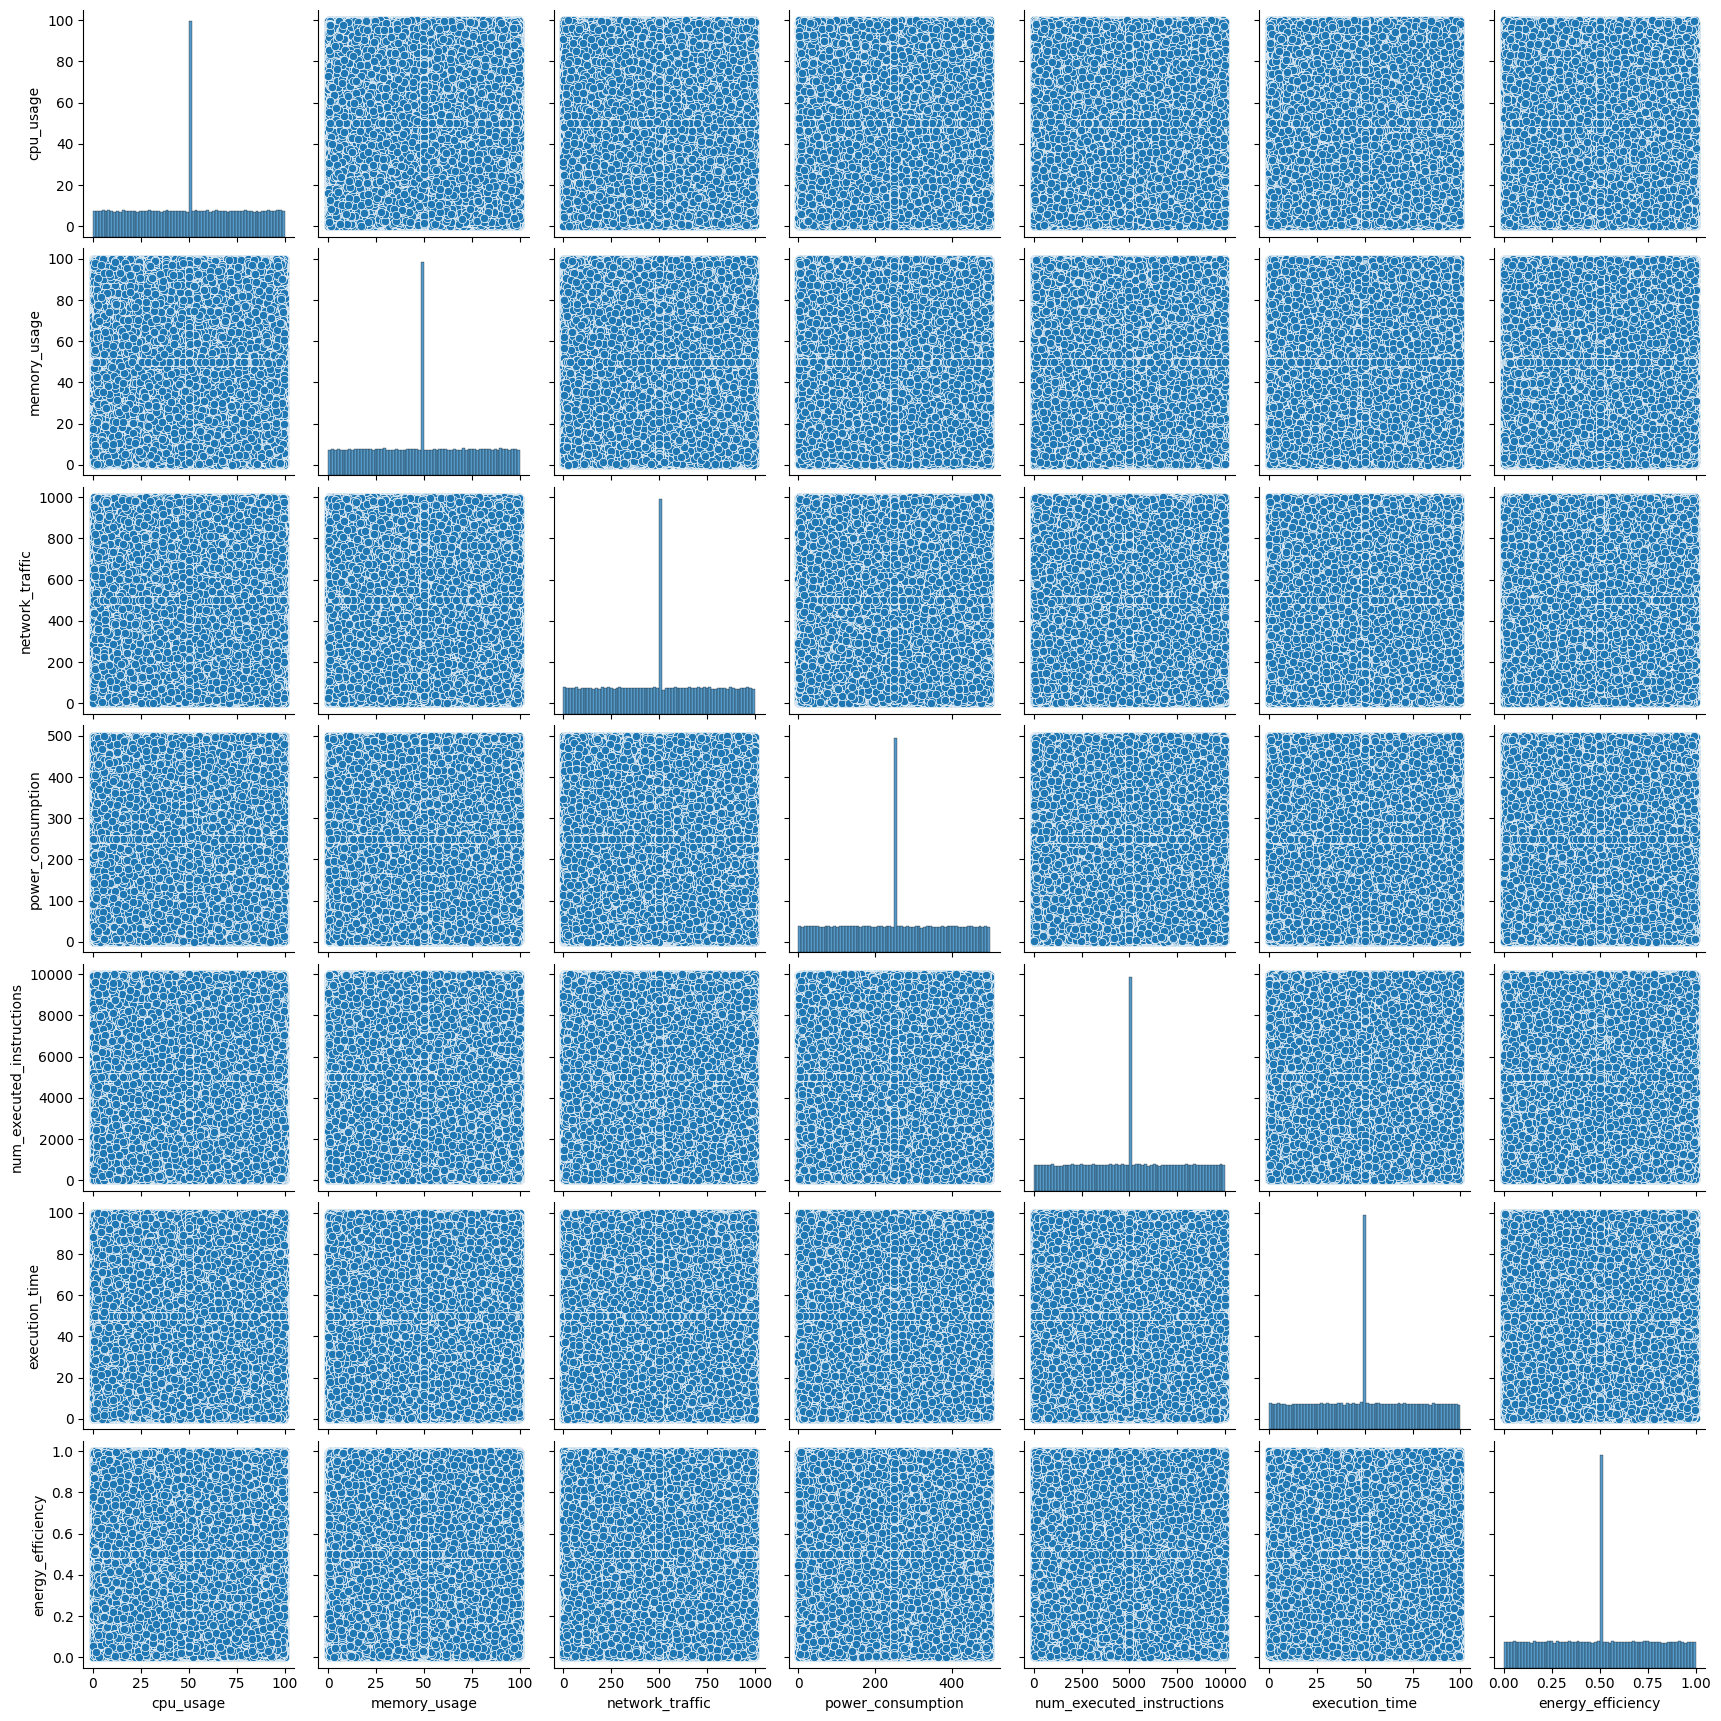

In [ ]:
df_sample = df.select(numeric_cols).sample(fraction=0.1, seed=42)
df_pd = df_sample.toPandas()

sns.pairplot(df_pd)
plt.show()


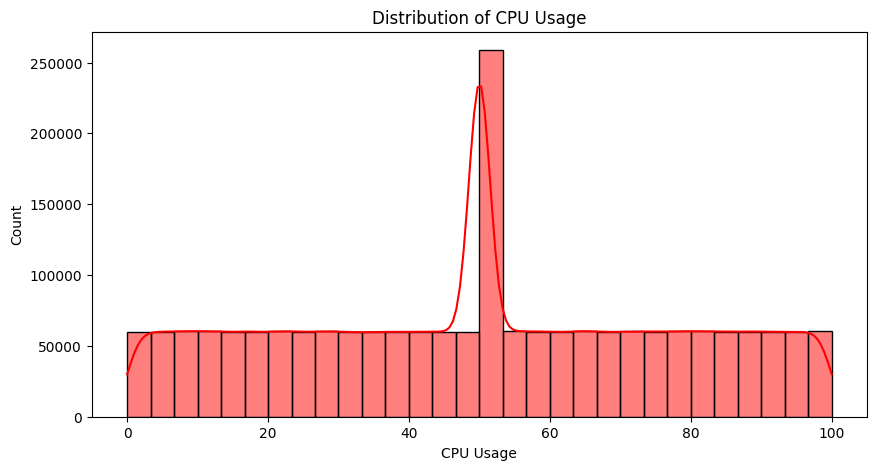

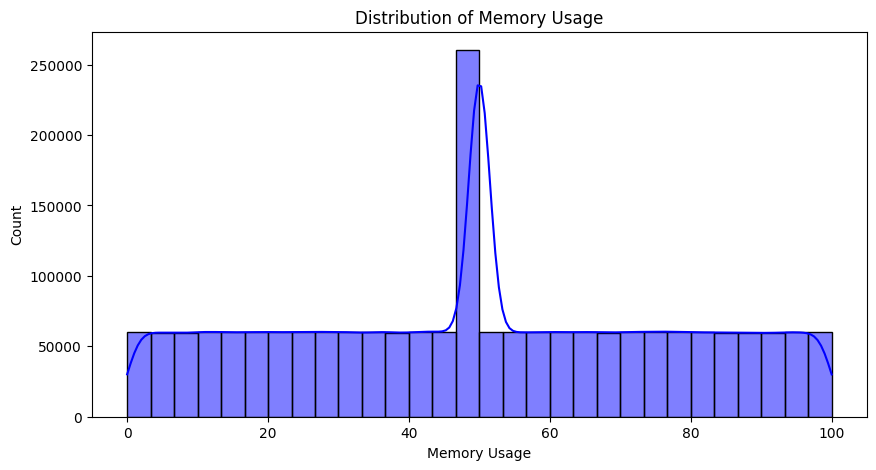

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df_pandas = df.select("cpu_usage", "memory_usage").toPandas()

plt.figure(figsize=(10, 5))
sns.histplot(df_pandas["cpu_usage"], bins=30, kde=True, color="red")
plt.xlabel("CPU Usage")
plt.title("Distribution of CPU Usage")
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(df_pandas["memory_usage"], bins=30, kde=True, color="blue")
plt.xlabel("Memory Usage")
plt.title("Distribution of Memory Usage")
plt.show()


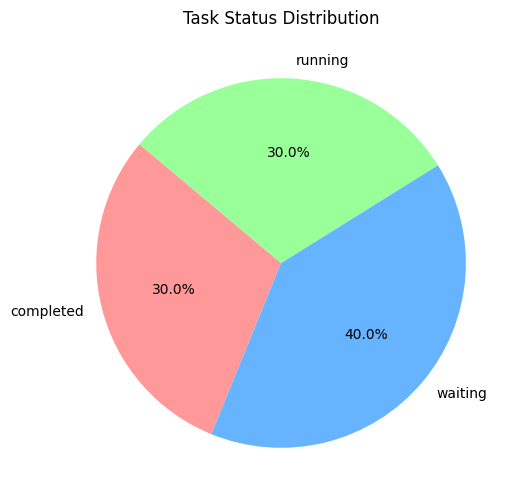

In [ ]:
task_status_counts = df.groupBy("task_status").count()

df_task_status_counts = task_status_counts.toPandas()

plt.figure(figsize=(6, 6))
plt.pie(df_task_status_counts["count"], labels=df_task_status_counts["task_status"],
        autopct="%1.1f%%", startangle=140, colors=["#ff9999", "#66b3ff", "#99ff99", "#ffcc99"])
plt.title("Task Status Distribution")
plt.show()

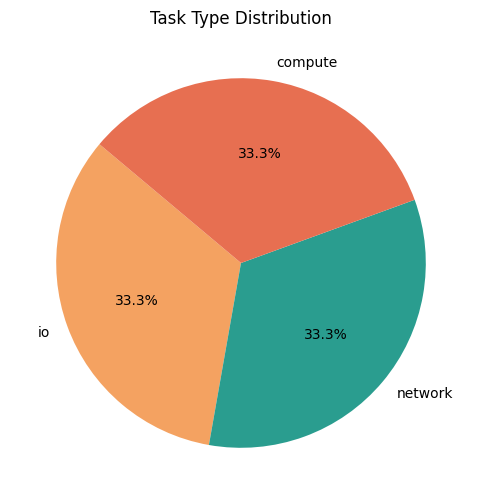

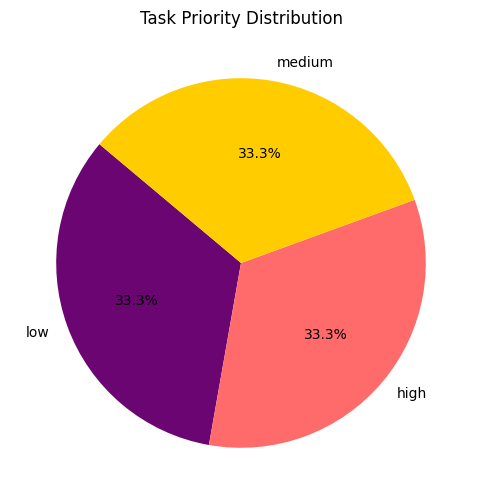

In [ ]:
task_status_counts = df.groupBy("task_status").count()
task_type_counts = df.groupBy("task_type").count()
task_priority_counts = df.groupBy("task_priority").count()

task_status_pandas = task_status_counts.toPandas()
task_type_pandas = task_type_counts.toPandas()
task_priority_pandas = task_priority_counts.toPandas()

def plot_pie_chart(df, column_name, title, colors=None):
    plt.figure(figsize=(6, 6))
    counts = df[column_name].value_counts()
    plt.pie(counts, labels=counts.index, autopct="%1.1f%%", startangle=140, colors=colors)
    plt.title(title)
    plt.show()

plot_pie_chart(task_type_pandas, "task_type", "Task Type Distribution", colors=["#f4a261", "#2a9d8f", "#e76f51", "#8ecae6"])

plot_pie_chart(task_priority_pandas, "task_priority", "Task Priority Distribution", colors=["#6a0572", "#ff6b6b", "#ffcc00", "#3d348b"])

In [ ]:
df = df.drop("vm_id", "timestamp")

In [ ]:
df.show()

+-----------------+------------------+------------------+------------------+-------------------------+------------------+-------------------+---------+-------------+-----------+
|        cpu_usage|      memory_usage|   network_traffic| power_consumption|num_executed_instructions|    execution_time|  energy_efficiency|task_type|task_priority|task_status|
+-----------------+------------------+------------------+------------------+-------------------------+------------------+-------------------+---------+-------------+-----------+
|54.88135039273247| 78.95086101800565|164.77597272736512| 287.8089860943348|                   7527.0| 69.34557502116084| 0.5535890138304125|  network|       medium|    waiting|
|71.51893663724195|29.901882588683115|  500.007571992804|362.27356881966176|                   5348.0| 41.39603965431024|0.34985621240730336|       io|         high|  completed|
|50.01223220607391| 92.70919512014967|203.67484711501893| 231.4679027444394|                   5483.0|24.60254

In [ ]:
from pyspark.ml.feature import StringIndexer

categorical_columns = ["task_type", "task_priority","task_status"]
df_encoded = df

for col_name in categorical_columns:
    indexer = StringIndexer(inputCol=col_name, outputCol=f"{col_name}_label").setHandleInvalid("keep")
    df_encoded = indexer.fit(df_encoded).transform(df_encoded)

    df_encoded = df_encoded.drop(col_name)

df_encoded.show()


+-----------------+------------------+------------------+------------------+-------------------------+------------------+-------------------+---------------+-------------------+-----------------+
|        cpu_usage|      memory_usage|   network_traffic| power_consumption|num_executed_instructions|    execution_time|  energy_efficiency|task_type_label|task_priority_label|task_status_label|
+-----------------+------------------+------------------+------------------+-------------------------+------------------+-------------------+---------------+-------------------+-----------------+
|54.88135039273247| 78.95086101800565|164.77597272736512| 287.8089860943348|                   7527.0| 69.34557502116084| 0.5535890138304125|            1.0|                0.0|              0.0|
|71.51893663724195|29.901882588683115|  500.007571992804|362.27356881966176|                   5348.0| 41.39603965431024|0.34985621240730336|            0.0|                1.0|              2.0|
|50.01223220607391| 

In [ ]:
X = df_encoded.drop("cpu_usage", "memory_usage", "network_traffic")

y = df_encoded.select("cpu_usage", "memory_usage", "network_traffic")

X.show(5)
y.show(5)

+------------------+-------------------------+------------------+-------------------+---------------+-------------------+-----------------+
| power_consumption|num_executed_instructions|    execution_time|  energy_efficiency|task_type_label|task_priority_label|task_status_label|
+------------------+-------------------------+------------------+-------------------+---------------+-------------------+-----------------+
| 287.8089860943348|                   7527.0| 69.34557502116084| 0.5535890138304125|            1.0|                0.0|              0.0|
|362.27356881966176|                   5348.0| 41.39603965431024|0.34985621240730336|            0.0|                1.0|              2.0|
| 231.4679027444394|                   5483.0|24.602548884707854|   0.79627697356617|            0.0|                0.0|              2.0|
|195.63995376557352|                   5876.0|16.456669858380668| 0.5295107822540652|            2.0|                1.0|              2.0|
|359.45153695723053|

In [ ]:
X_train, X_test = X.randomSplit([0.8, 0.2], seed=42)
y_train, y_test = y.randomSplit([0.8, 0.2], seed=42)

print("Training set size:", X_train.count(), y_train.count())
print("Testing set size:", X_test.count(), y_test.count())

Training set size: 1600370 1600370
Testing set size: 399630 399630


In [ ]:
from pyspark.sql.functions import mean
import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor

X_train_pd = X_train.toPandas()
X_test_pd = X_test.toPandas()
y_train_pd = y_train.toPandas()
y_test_pd = y_test.toPandas()

models_lgbm = {}
models_rf = {}
predictions_lgbm = {}
predictions_rf = {}
models_xgb = {}
predictions_xgb = {}

for target in y_train_pd.columns:
    print(f"Training models for target: {target}")

    model_lgbm = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.1, num_leaves=31)
    model_lgbm.fit(X_train_pd, y_train_pd[target])  # Training
    models_lgbm[target] = model_lgbm
    predictions_lgbm[target] = model_lgbm.predict(X_test_pd)

    model_xgb = xgb.XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        objective="reg:squarederror",
        tree_method="hist",
        random_state=42
    )
    model_xgb.fit(X_train_pd, y_train_pd[target])
    models_xgb[target] = model_xgb
    predictions_xgb[target] = model_xgb.predict(X_test_pd)

print("\nModel training completed!")


Training models for target: cpu_usage
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.043274 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1029
[LightGBM] [Info] Number of data points in the train set: 1600370, number of used features: 7
[LightGBM] [Info] Start training from score 50.019430
Training models for target: memory_usage
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.247197 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1029
[LightGBM] [Info] Number of data points in the train set: 1600370, number of used features: 7
[LightGBM] [Info] Start training from score 49.972123
Training models for target: network_traffic
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.043671 seconds.
You can set `force_ro

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = {"Target": [], "Model": [], "MAE": [], "MSE": [], "RMSE": [], "R2": []}

def evaluate_model(model_name, target, y_test, predictions):
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = mse ** 0.5
    r2 = r2_score(y_test, predictions)

    results["Target"].append(target)
    results["Model"].append(model_name)
    results["MAE"].append(mae)
    results["MSE"].append(mse)
    results["RMSE"].append(rmse)
    results["R2"].append(r2)

for target in y_test_pd.columns:
    evaluate_model("LightGBM", target, y_test_pd[target], predictions_lgbm[target])

for target in y_test_pd.columns:
    evaluate_model("XGBoost", target, y_test_pd[target], predictions_xgb[target])

import pandas as pd
results_df = pd.DataFrame(results)

from IPython.display import display
display(results_df)

,Target,Model,MAE,MSE,RMSE,R2
0,cpu_usage,LightGBM,0.091756,0.012841,0.113317,0.999983
1,memory_usage,LightGBM,20.341175,675.730952,25.994825,0.097654
2,network_traffic,LightGBM,223.781274,74411.398962,272.784528,0.007769
3,cpu_usage,XGBoost,0.100468,0.015287,0.123641,0.999980
4,memory_usage,XGBoost,20.353152,675.982958,25.999672,0.097318
5,network_traffic,XGBoost,224.034755,74454.452536,272.863432,0.007195
